First 5 ages:
[ 7.36718202 17.16214321 13.44389701 11.17719423  3.65231689]

First 5 heights:
[ 92.23739436 209.01278238 153.39113635 122.63167531  72.92602072]

First 5 rows of X:
[[ 1.          7.36718202  2.36718202  0.        ]
 [ 1.         17.16214321 12.16214321  5.16214321]
 [ 1.         13.44389701  8.44389701  1.44389701]
 [ 1.         11.17719423  6.17719423  0.        ]
 [ 1.          3.65231689  0.          0.        ]]
Weights learned by our model:
[21.54127907 11.98984313 -5.20191236  8.75502637]
Weights learned by sklearn:
[51.85681659  4.52927644  3.61278992  6.76039468]


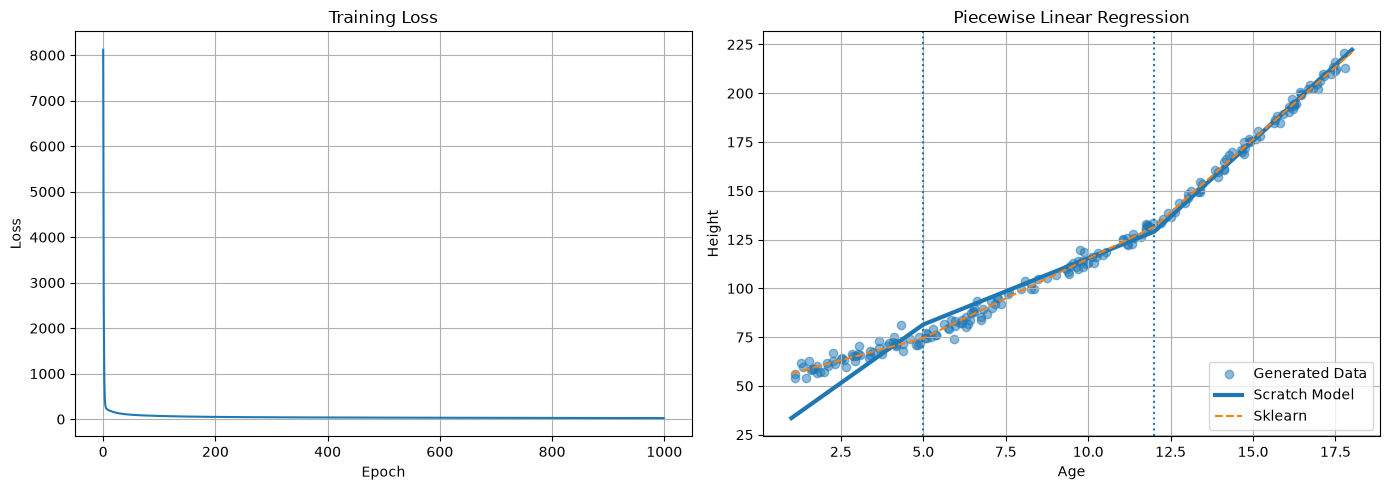

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLinearRegression



# GENERATING AGE AND HEIGHT DATA

import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

ages = np.random.uniform(1, 18, 200)
heights = np.zeros(200)

# print(f"heights: ", heights.shape)
# print(f"heights", heights)
# print(f"heights dim: ", heights.ndim)

# Create height data
for i, age in enumerate(ages):

    base_height = 50 + 5 * age

    # Growth changes after age 5
    heihgt_1 = 3 * max(0, age - 5)

    # Growth changes again after age 12
    height_2 = 7 * max(0, age - 12)

    # Add some random noise
    noise = np.random.normal(0, 2.5)

    heights[i] = base_height + heihgt_1 + height_2 + noise

# Knot points
knot1 = 5
knot2 = 12


# Create the feature matrix
# X = [1, age, max(0, age-5), max(0, age-12)]

X = np.column_stack([
    np.ones(len(ages)),
    ages,
    np.maximum(0, ages - knot1),
    np.maximum(0, ages - knot2)
])

y = heights.reshape(-1, 1)


print("First 5 ages:")
print(ages[:5])

print("\nFirst 5 heights:")
print(heights[:5])

print("\nFirst 5 rows of X:")
print(X[:5])

# LINEAR REGRESSION FROM SCRATCH
# ============================================================

learning_rate = 0.01
epochs = 1000

# Start all weights at 0
weights = np.zeros((X.shape[1], 1))

# Store loss after every epoch
loss_history = []


# Gradient descent
for epoch in range(epochs):

    predictions = X.dot(weights)

    error = predictions - y

    # Calculate loss
    loss = (1 / (2 * len(X))) * np.sum(error ** 2)

    loss_history.append(loss)

    # Calculate gradients
    gradients = (1 / len(X)) * X.T.dot(error)
    
    # Update weights
    weights = weights - learning_rate * gradients


# Print learned weights
print("Weights learned by our model:")
print(weights.flatten())



# Compare with sklearn

from sklearn.linear_model import LinearRegression

# We already have a column of 1s in X,
# so we don't need another intercept.
sklearn_model = LinearRegression(fit_intercept=False)

sklearn_model.fit(X, y)

print("Weights learned by sklearn:")
print(sklearn_model.coef_.flatten())


# Create smooth age values for plotting
smooth_ages = np.linspace(1, 18, 500)

# Create the same knot features for smooth_ages
X_smooth = np.column_stack([
    np.ones(len(smooth_ages)),
    smooth_ages,
    np.maximum(0, smooth_ages - knot1),
    np.maximum(0, smooth_ages - knot2)
])

# Predictions from our model
scratch_predictions = X_smooth.dot(weights)

# Predictions from sklearn
sklearn_predictions = sklearn_model.predict(X_smooth)

# PLOTS

plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)


# Data and predictions
plt.subplot(1, 2, 2)

# Original generated data
plt.scatter(
    ages,
    heights,
    alpha=0.5,
    label="Generated Data"
)


# Our model prediction
plt.plot(
    smooth_ages,
    scratch_predictions,
    linewidth=3,
    label="Scratch Model"
)


# Sklearn prediction
plt.plot(
    smooth_ages,
    sklearn_predictions,
    linestyle="--",
    label="Sklearn"
)


# Show the knot points
plt.axvline(
    knot1,
    linestyle=":"
)

plt.axvline(
    knot2,
    linestyle=":"
)


plt.title("Piecewise Linear Regression")

plt.xlabel("Age")

plt.ylabel("Height")

plt.legend()

plt.grid(True)


plt.tight_layout()

plt.show()